# COMP6252 CW1: Music Genre Classification

**Student:** Isha Girish Kulkarni &nbsp;|&nbsp; **ECS ID:** 37642456 &nbsp;|&nbsp; **Email:** igk1g25@soton.ac.uk

This notebook implements six genre classification models on the **GTZAN dataset** (999 samples, 10 genres).  
- **Net1–Net4** use MEL spectrogram images (image modality).  
- **Net5** uses raw audio MFCC sequences (audio modality).  
- **Net6** augments the audio training set with GAN-generated samples.

## Setup
Install required packages and configure environment variables.

In [ ]:
pip install torch torchaudio torchvision soundfile  torchvision matplotlib

## Imports & Configuration
Load all libraries and set global constants (random seeds, batch size, image transforms).

In [2]:
import os, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as AT
from torch.utils.data import (DataLoader, Dataset, random_split,
                               ConcatDataset, TensorDataset)
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf


SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch : {torch.__version__}')
print(f'torchaudio: {torchaudio.__version__}')


Device: cuda
PyTorch : 2.11.0+cu126
torchaudio: 2.11.0+cu126


## Image-based Classification (Net1–Net4)
### Dataset Loading
Load the GTZAN MEL spectrogram images (`Data/images_original/`) split into 80/10/10 train/val/test sets.

In [ ]:
# Load Image Dataset for Net 1 to 4.
IMG_DIR    = 'Data/images_original'
BATCH_SIZE = 32

img_transform = transforms.Compose([
    transforms.Resize((180, 180)),                     
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],         
                         [0.229, 0.224, 0.225])
])

full_img = datasets.ImageFolder(root=IMG_DIR, transform=img_transform)
print(f'Image dataset :{len(full_img)} samples, Classes: {full_img.classes}')

n_img   = len(full_img)
n_tr    = int(0.70 * n_img)
n_vl    = int(0.20 * n_img)
n_te    = n_img - n_tr - n_vl

img_train, img_val, img_test = random_split(
    full_img, [n_tr, n_vl, n_te],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'Training Data: {n_tr}  Validation Data: {n_vl}  Test Data: {n_te}')

img_train_ldr = DataLoader(img_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
img_val_ldr   = DataLoader(img_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
img_test_ldr  = DataLoader(img_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Image dataset — 999 samples, classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Train: 699  Val: 199  Test: 101


#### Net1 Fully Connected Network
Baseline model: two hidden layers with BatchNorm1d and Dropout.

In [ ]:
# Net1: Fully Connected (2 hidden layers)
# Dropout + BatchNorm1d reduce overfitting on the large 97200-dim input.
class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 180 * 180, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

_x = torch.zeros(2, 3, 180, 180)
print('Net1 output:', Net1()(_x).shape)


Net1 output: torch.Size([2, 10])


#### Net2 CNN
Convolutional network with three Conv-Pool blocks and a fully connected head.

In [ ]:
# Net2: CNN (Figure 1 architecture) 
# conv1->conv2->MaxPool1->conv3->conv4->MaxPool2->out_features=256->FC+ReLU->FC
# Dropout after pooling layers reduces overfitting. Optimizer: Adam lr=5e-4
class Net2(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32,  3, padding=1), nn.ReLU(),   
            nn.Conv2d(32, 64,  3, padding=1), nn.ReLU(),   
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)         
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1), nn.ReLU(),  
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),  
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)         
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(),                
            nn.Linear(128, 10)                        
        )
    def forward(self, x):
        return self.classifier(self.pool(self.block2(self.block1(x))))

print('Net2 output:', Net2()(_x).shape)


Net2 output: torch.Size([2, 10])


#### Net3 CNN + Batch Normalisation
Net2 extended with BatchNorm2d after every Conv2d layer.

In [ ]:
# Net3: CNN + Batch Normalisation 
# Net2 + BatchNorm2d after every Conv2d. Optimizer: Adam lr=5e-4
class Net3(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.block2(self.block1(x))))

print('Net3 output:', Net3()(_x).shape)


Net3 output: torch.Size([2, 10])


#### Net4 CNN + BatchNorm + RMSProp
Same architecture as Net3; optimiser switched from Adam to RMSProp.

In [ ]:
# Net4: CNN + Batch Normalisation + RMSProp 
# Same architecture to Net3; only the optimizer is RMSprop (lr=1e-3).
class Net4(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.block2(self.block1(x))))

print('Net4 output:', Net4()(_x).shape)


Net4 output: torch.Size([2, 10])


### Training Helpers
Shared `train_epoch` and `evaluate` functions used by all image-based networks.

In [ ]:
# Training helpers 
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def run_training(model, optimizer, epochs, label,
                 tr_ldr=None, vl_ldr=None, te_ldr=None,
                 scheduler=None, patience=None):
    """Train for `epochs` epochs with optional LR scheduling and early stopping.
    Returns (history_dict, test_accuracy).
    """
    if tr_ldr is None: tr_ldr = img_train_ldr
    if vl_ldr is None: vl_ldr = img_val_ldr
    if te_ldr is None: te_ldr = img_test_ldr

    criterion  = nn.CrossEntropyLoss()
    history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val   = float('inf')
    best_state = None
    wait       = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, tr_ldr, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, vl_ldr, criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'  ].append(vl_loss)
        history['train_acc' ].append(tr_acc)
        history['val_acc'   ].append(vl_acc)

        if scheduler is not None:
            scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d}/{epochs}  '
                  f'Train Loss {tr_loss:.4f} Acc {tr_acc:.4f}  '
                  f'Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}')

        # track best weights (used for early stopping)
        if vl_loss < best_val:
            best_val   = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        elif patience is not None:
            wait += 1
            if wait >= patience:
                print(f'[{label}] Early stopping at epoch {epoch}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    _, test_acc = evaluate(model, te_ldr, criterion)
    print(f'\n[{label}]  >>> TEST Accuracy: {test_acc:.4f} <<<\n')
    return history, test_acc


def plot_history(histories, labels, metric='acc', fname=None):
    fig, axes = plt.subplots(1, len(histories), figsize=(5 * len(histories), 4))
    if len(histories) == 1: axes = [axes]
    for ax, hist, lbl in zip(axes, histories, labels):
        ax.plot(hist[f'train_{metric}'], label='Train')
        ax.plot(hist[f'val_{metric}'],   label='Val', linestyle='--')
        ax.set_title(lbl); ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize()); ax.legend()
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150)
    plt.show()

print('Helpers defined.')


Helpers defined.


### Training: Net1 (50 & 100 epochs)

In [ ]:
# Train Net1 (50 & 100 epochs) 
print('=' * 60)
print('Net1 — Fully Connected | 50 epochs')
net1_50  = Net1().to(device)
opt1_50  = optim.Adam(net1_50.parameters(), lr=1e-3, weight_decay=1e-4)
sch1_50  = optim.lr_scheduler.StepLR(opt1_50, step_size=20, gamma=0.5)
hist1_50, acc1_50 = run_training(net1_50, opt1_50, 50, 'Net1 50ep', scheduler=sch1_50)

print('=' * 60)
print('Net1 — Fully Connected | 100 epochs')
net1_100 = Net1().to(device)
opt1_100 = optim.Adam(net1_100.parameters(), lr=1e-3, weight_decay=1e-4)
sch1_100 = optim.lr_scheduler.StepLR(opt1_100, step_size=30, gamma=0.5)
hist1_100, acc1_100 = run_training(net1_100, opt1_100, 100, 'Net1 100ep', scheduler=sch1_100)

Net1 — Fully Connected | 50 epochs
[Net1 50ep] Epoch   1/50  Train Loss 2.0310 Acc 0.2661  Val Loss 2.8956 Acc 0.1910
[Net1 50ep] Epoch  10/50  Train Loss 0.2951 Acc 0.9456  Val Loss 3.0053 Acc 0.2513
[Net1 50ep] Epoch  20/50  Train Loss 0.0937 Acc 0.9800  Val Loss 3.0770 Acc 0.2161
[Net1 50ep] Epoch  30/50  Train Loss 0.0411 Acc 0.9871  Val Loss 2.2439 Acc 0.3869
[Net1 50ep] Epoch  40/50  Train Loss 0.0189 Acc 0.9986  Val Loss 2.9344 Acc 0.3618
[Net1 50ep] Epoch  50/50  Train Loss 0.0153 Acc 0.9971  Val Loss 1.8373 Acc 0.4724

[Net1 50ep]  >>> TEST Accuracy: 0.4752 <<<

Net1 — Fully Connected | 100 epochs
[Net1 100ep] Epoch   1/100  Train Loss 2.0243 Acc 0.3033  Val Loss 2.4521 Acc 0.2412
[Net1 100ep] Epoch  10/100  Train Loss 0.2668 Acc 0.9499  Val Loss 1.9344 Acc 0.3769
[Net1 100ep] Epoch  20/100  Train Loss 0.1246 Acc 0.9685  Val Loss 4.5278 Acc 0.2462
[Net1 100ep] Epoch  30/100  Train Loss 0.0679 Acc 0.9800  Val Loss 3.0449 Acc 0.3216
[Net1 100ep] Epoch  40/100  Train Loss 0.0311 

### Training: Net2 (50 & 100 epochs)

In [ ]:
# Train Net2 (50 & 100 epochs)
print("=" * 60)
print("Net2 — CNN (Figure 1) | 50 epochs")
net2_50  = Net2().to(device)
opt2_50  = optim.Adam(net2_50.parameters(), lr=1e-3, weight_decay=1e-4)
sch2_50  = optim.lr_scheduler.StepLR(opt2_50, step_size=20, gamma=0.5)
hist2_50, acc2_50 = run_training(net2_50, opt2_50, 50, "Net2 50ep", scheduler=sch2_50)

print("=" * 60)
print("Net2 — CNN (Figure 1) | 100 epochs")
net2_100 = Net2().to(device)
opt2_100 = optim.Adam(net2_100.parameters(), lr=1e-3, weight_decay=1e-4)
sch2_100 = optim.lr_scheduler.StepLR(opt2_100, step_size=30, gamma=0.5)
hist2_100, acc2_100 = run_training(net2_100, opt2_100, 100, "Net2 100ep", scheduler=sch2_100)

Net2 — CNN (Figure 1) | 50 epochs
[Net2 50ep] Epoch   1/50  Train Loss 2.3078 Acc 0.0844  Val Loss 2.3002 Acc 0.1005
[Net2 50ep] Epoch  10/50  Train Loss 2.0471 Acc 0.2089  Val Loss 2.0331 Acc 0.2060
[Net2 50ep] Epoch  20/50  Train Loss 1.9814 Acc 0.2461  Val Loss 1.9940 Acc 0.2111
[Net2 50ep] Epoch  30/50  Train Loss 1.8828 Acc 0.2790  Val Loss 1.8642 Acc 0.3467
[Net2 50ep] Epoch  40/50  Train Loss 1.6483 Acc 0.3920  Val Loss 1.6884 Acc 0.3819
[Net2 50ep] Epoch  50/50  Train Loss 1.5310 Acc 0.4378  Val Loss 1.6072 Acc 0.4724

[Net2 50ep]  >>> TEST Accuracy: 0.4257 <<<

Net2 — CNN (Figure 1) | 100 epochs
[Net2 100ep] Epoch   1/100  Train Loss 2.3092 Acc 0.1187  Val Loss 2.3031 Acc 0.1759
[Net2 100ep] Epoch  10/100  Train Loss 2.0605 Acc 0.2103  Val Loss 2.0133 Acc 0.2111
[Net2 100ep] Epoch  20/100  Train Loss 2.0056 Acc 0.2175  Val Loss 2.0226 Acc 0.1960
[Net2 100ep] Epoch  30/100  Train Loss 1.6934 Acc 0.3834  Val Loss 1.7250 Acc 0.3719
[Net2 100ep] Epoch  40/100  Train Loss 1.5699 Ac

### Training: Net3 (50 & 100 epochs)

In [ ]:
# Train Net3 (50 & 100 epochs)
print('=' * 60)
print('Net3 — CNN + BatchNorm | 50 epochs')
net3_50  = Net3().to(device)
opt3_50  = optim.Adam(net3_50.parameters(), lr=5e-4, weight_decay=1e-4)
sch3_50  = optim.lr_scheduler.CosineAnnealingLR(opt3_50, T_max=50)
hist3_50, acc3_50 = run_training(net3_50, opt3_50, 50, 'Net3 50ep', scheduler=sch3_50)

print('=' * 60)
print('Net3 — CNN + BatchNorm | 100 epochs')
net3_100 = Net3().to(device)
opt3_100 = optim.Adam(net3_100.parameters(), lr=5e-4, weight_decay=1e-4)
sch3_100 = optim.lr_scheduler.CosineAnnealingLR(opt3_100, T_max=100)
hist3_100, acc3_100 = run_training(net3_100, opt3_100, 100, 'Net3 100ep', scheduler=sch3_100)

Net3 — CNN + BatchNorm | 50 epochs
[Net3 50ep] Epoch   1/50  Train Loss 2.2654 Acc 0.1373  Val Loss 2.2178 Acc 0.1960
[Net3 50ep] Epoch  10/50  Train Loss 1.6837 Acc 0.3705  Val Loss 1.6165 Acc 0.4070
[Net3 50ep] Epoch  20/50  Train Loss 1.4602 Acc 0.4907  Val Loss 1.4551 Acc 0.5025
[Net3 50ep] Epoch  30/50  Train Loss 1.3285 Acc 0.5422  Val Loss 1.3922 Acc 0.5427
[Net3 50ep] Epoch  40/50  Train Loss 1.2645 Acc 0.5594  Val Loss 1.3531 Acc 0.5477
[Net3 50ep] Epoch  50/50  Train Loss 1.2572 Acc 0.5694  Val Loss 1.3474 Acc 0.5327

[Net3 50ep]  >>> TEST Accuracy: 0.6634 <<<

Net3 — CNN + BatchNorm | 100 epochs
[Net3 100ep] Epoch   1/100  Train Loss 2.2258 Acc 0.1688  Val Loss 2.1785 Acc 0.1759
[Net3 100ep] Epoch  10/100  Train Loss 1.5894 Acc 0.4192  Val Loss 1.8640 Acc 0.2915
[Net3 100ep] Epoch  20/100  Train Loss 1.4396 Acc 0.4835  Val Loss 1.4941 Acc 0.4121
[Net3 100ep] Epoch  30/100  Train Loss 1.4025 Acc 0.5050  Val Loss 1.3995 Acc 0.5126
[Net3 100ep] Epoch  40/100  Train Loss 1.2461 

### Training: Net4 (50 & 100 epochs)

In [ ]:
# Train Net4 (50 & 100 epochs)
print('=' * 60)
print('Net4 — CNN + BatchNorm + RMSprop | 50 epochs')
net4_50  = Net4().to(device)
opt4_50  = optim.RMSprop(net4_50.parameters(), lr=1e-3, weight_decay=1e-4)
sch4_50  = optim.lr_scheduler.StepLR(opt4_50, step_size=20, gamma=0.5)
hist4_50, acc4_50 = run_training(net4_50, opt4_50, 50, 'Net4 50ep', scheduler=sch4_50)

print('=' * 60)
print('Net4 — CNN + BatchNorm + RMSprop | 100 epochs')
net4_100 = Net4().to(device)
opt4_100 = optim.RMSprop(net4_100.parameters(), lr=1e-3, weight_decay=1e-4)
sch4_100 = optim.lr_scheduler.StepLR(opt4_100, step_size=30, gamma=0.5)
hist4_100, acc4_100 = run_training(net4_100, opt4_100, 100, 'Net4 100ep', scheduler=sch4_100)


Net4 — CNN + BatchNorm + RMSprop | 50 epochs
[Net4 50ep] Epoch   1/50  Train Loss 2.2395 Acc 0.1588  Val Loss 2.1163 Acc 0.1809
[Net4 50ep] Epoch  10/50  Train Loss 1.6358 Acc 0.4092  Val Loss 1.5734 Acc 0.4523
[Net4 50ep] Epoch  20/50  Train Loss 1.4460 Acc 0.4764  Val Loss 1.4880 Acc 0.4673
[Net4 50ep] Epoch  30/50  Train Loss 1.3303 Acc 0.5422  Val Loss 1.5659 Acc 0.4774
[Net4 50ep] Epoch  40/50  Train Loss 1.2514 Acc 0.5565  Val Loss 1.3384 Acc 0.5528
[Net4 50ep] Epoch  50/50  Train Loss 1.1990 Acc 0.5880  Val Loss 1.3217 Acc 0.5327

[Net4 50ep]  >>> TEST Accuracy: 0.5842 <<<

Net4 — CNN + BatchNorm + RMSprop | 100 epochs
[Net4 100ep] Epoch   1/100  Train Loss 2.2374 Acc 0.1617  Val Loss 2.0626 Acc 0.2312
[Net4 100ep] Epoch  10/100  Train Loss 1.6135 Acc 0.4092  Val Loss 1.5786 Acc 0.4020
[Net4 100ep] Epoch  20/100  Train Loss 1.4667 Acc 0.4735  Val Loss 1.6029 Acc 0.3769
[Net4 100ep] Epoch  30/100  Train Loss 1.3737 Acc 0.4979  Val Loss 1.4404 Acc 0.5276
[Net4 100ep] Epoch  40/100

### Results (Net1–Net4)
Comparison table and grouped bar chart across 50 and 100 epochs.


Model                                   50ep    100ep
-------------------------------------------------------
Net1 — Fully Connected                0.4752   0.3663
Net2 — CNN                            0.4257   0.5050
Net3 — CNN + BatchNorm                0.6634   0.6436
Net4 — CNN + BatchNorm + RMSprop      0.5842   0.6436


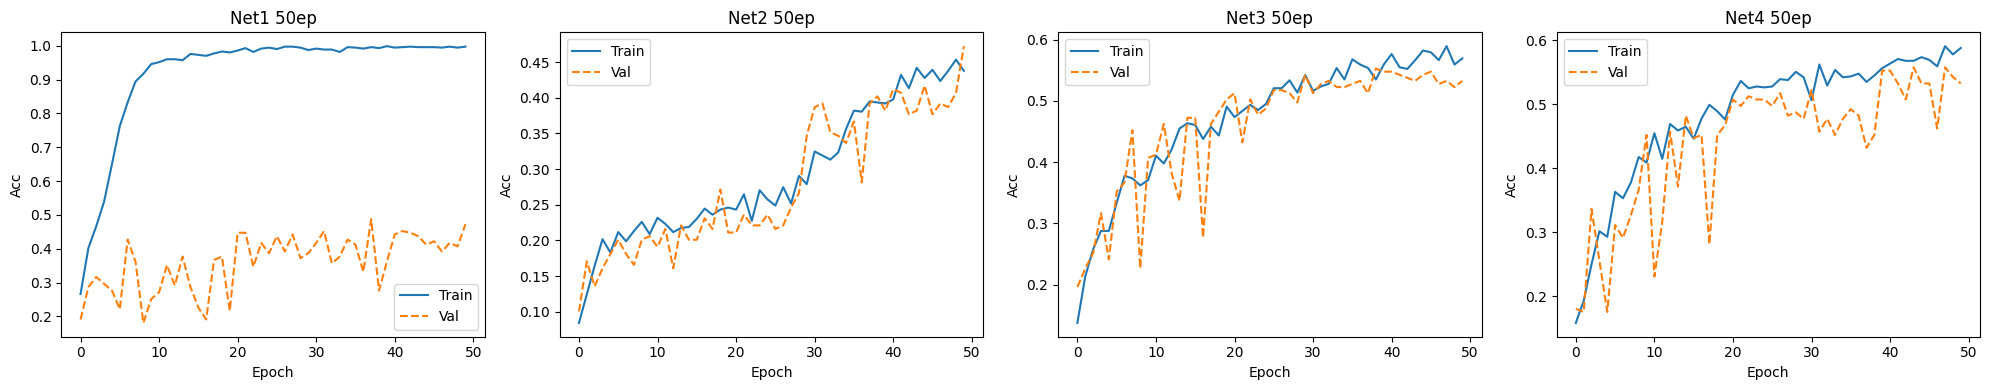

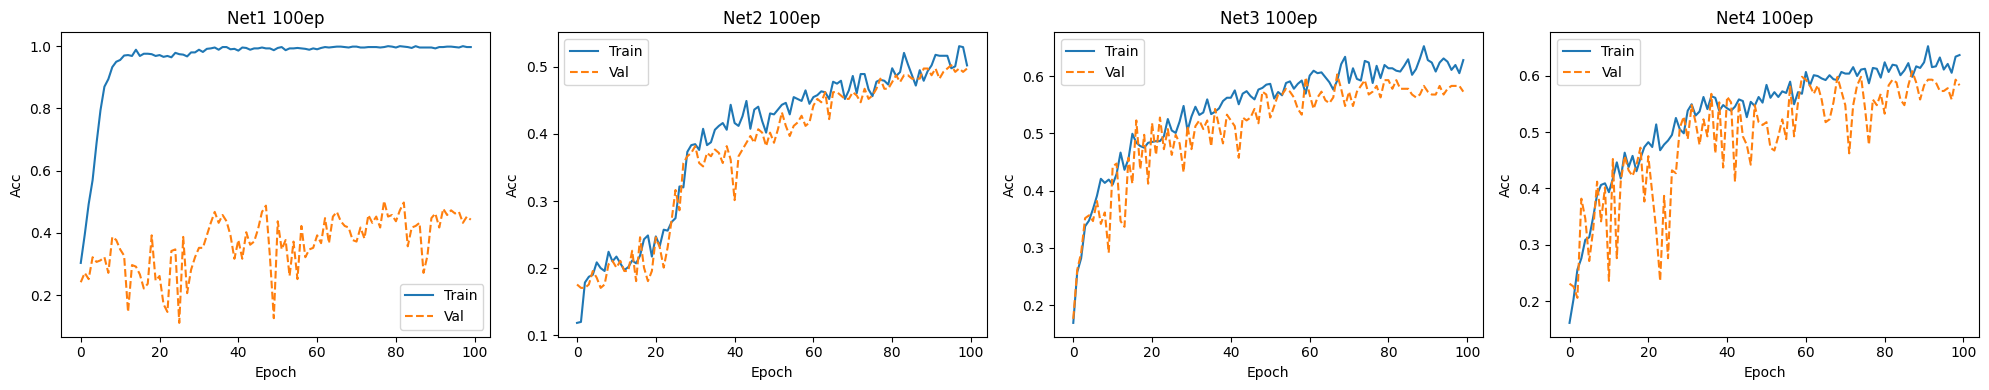

In [ ]:
# Results Summary Net1–4 (50 & 100 epochs) 
results = {
    'Net1 — Fully Connected'          : (acc1_50,  acc1_100),
    'Net2 — CNN'                      : (acc2_50,  acc2_100),
    'Net3 — CNN + BatchNorm'          : (acc3_50,  acc3_100),
    'Net4 — CNN + BatchNorm + RMSprop': (acc4_50,  acc4_100),
}

# Printed table with delta values
print('\n' + f"{'Model':<35} {'50ep':>8} {'100ep':>8} {'Delta':>8}")
print('-' * 63)
for name, (a50, a100) in results.items():
    delta = a100 - a50
    sign  = '+' if delta >= 0 else ''
    print(f"{name:<35} {a50:>8.4f} {a100:>8.4f} {sign}{delta:>7.4f}")

# Grouped bar chart for comparison: 50ep vs 100ep 
labels  = ['Net1\nFC', 'Net2\nCNN', 'Net3\nCNN+BN', 'Net4\nCNN+BN\n+RMSprop']
acc_50  = [acc1_50,  acc2_50,  acc3_50,  acc4_50]
acc_100 = [acc1_100, acc2_100, acc3_100, acc4_100]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars50  = ax.bar(x - width/2, [a * 100 for a in acc_50],  width,
                 label='50 epochs',  color='steelblue',  alpha=0.85)
bars100 = ax.bar(x + width/2, [a * 100 for a in acc_100], width,
                 label='100 epochs', color='darkorange', alpha=0.85)

for bar in list(bars50) + list(bars100):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Net1-4 Test Accuracy: 50 vs 100 Epochs', fontsize=13)
ax.set_ylim(0, 80)
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='Random baseline (10%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_50_100ep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_50_100ep.png')

# Individual training curves
plot_history([hist1_50, hist2_50, hist3_50, hist4_50],
             ['Net1 50ep', 'Net2 50ep', 'Net3 50ep', 'Net4 50ep'],
             metric='acc', fname='accuracy_50epochs.png')

plot_history([hist1_100, hist2_100, hist3_100, hist4_100],
             ['Net1 100ep', 'Net2 100ep', 'Net3 100ep', 'Net4 100ep'],
             metric='acc', fname='accuracy_100epochs.png')


## Audio-based Classification (Net5–Net6)
### Audio Dataset
Load raw WAV files from `Data/genres_original/`, extract (10 × 40) MFCC sequences.

In [ ]:
# Audio Dataset for Net5 & Net6 

AUDIO_DIR = "Data/genres_original"
N_MFCC    = 40    # MFCC coefficients per window
N_SEGS    = 10    # split each clip into 10 equal time windows
GENRES    = sorted(os.listdir(AUDIO_DIR))
LABEL_MAP = {g: i for i, g in enumerate(GENRES)}
print("Genres:", GENRES)

class AudioMFCCDataset(torch.utils.data.Dataset):

    def __init__(self, audio_dir, n_mfcc=N_MFCC, n_segs=N_SEGS):
        self.samples = []
        self.n_segs  = n_segs
        self.mfcc_fn = AT.MFCC(
            sample_rate=22050, n_mfcc=n_mfcc,
            melkwargs={"n_fft": 2048, "hop_length": 512, "n_mels": 128}
        )
        skipped = 0
        for genre in sorted(os.listdir(audio_dir)):
            gpath = os.path.join(audio_dir, genre)
            if not os.path.isdir(gpath): continue
            for fname in sorted(os.listdir(gpath)):
                if not fname.endswith(".wav"): continue
                fpath = os.path.join(gpath, fname)
                try:
                    sf.info(fpath) 
                    self.samples.append((fpath, LABEL_MAP[genre]))
                except Exception:
                    skipped += 1
        if skipped:
            print(f"Skipped {skipped} unreadable file(s).")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        data, sr = sf.read(path, dtype="float32", always_2d=True)
        wav = torch.from_numpy(data.T).mean(0, keepdim=True) 
        if sr != 22050:
            wav = AT.Resample(sr, 22050)(wav)
        mfcc = self.mfcc_fn(wav).squeeze(0)
        total = mfcc.shape[1]
        seg_len = total // self.n_segs
        segs = []
        for i in range(self.n_segs):
            window = mfcc[:, i * seg_len : (i + 1) * seg_len] 
            segs.append(window.mean(dim=1))
        feat = torch.stack(segs)
        feat = (feat - feat.mean()) / (feat.std() + 1e-8)
        return feat.float(), torch.tensor(label, dtype=torch.long)
audio_ds = AudioMFCCDataset(AUDIO_DIR)
x0, y0   = audio_ds[0]
print(f"Total: {len(audio_ds)}  sample shape: {x0.shape}  label: {y0}")

na    = len(audio_ds)
na_tr = int(0.70 * na)
na_vl = int(0.20 * na)
na_te = na - na_tr - na_vl

a_train, a_val, a_test = random_split(
    audio_ds, [na_tr, na_vl, na_te],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Audio  Train: {na_tr}  Val: {na_vl}  Test: {na_te}")

a_tr_ldr = DataLoader(a_train, batch_size=32, shuffle=True,  num_workers=0)
a_vl_ldr = DataLoader(a_val,   batch_size=32, shuffle=False, num_workers=0)
a_te_ldr = DataLoader(a_test,  batch_size=32, shuffle=False, num_workers=0)


Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Skipped 1 unreadable file(s).
Total: 999  sample shape: torch.Size([10, 40])  label: 0
Audio  Train: 699  Val: 199  Test: 101


#### Net5 Bidirectional LSTM
Processes MFCC sequences with a BiLSTM, mean-pools hidden states, then classifies with two FC layers.

In [ ]:
# Net5: Bidirectional LSTM 
# Input (batch,10,40) -> BiLSTM(hidden=64) -> mean pool -> FC(128->64->10)
# Optimizer: Adam lr=1e-3, wd=1e-4 | Early stop on val_acc, patience=20

class Net5(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=N_MFCC, hidden_size=64, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out.mean(dim=1))

_a = torch.zeros(2, N_SEGS, N_MFCC)
print('Net5 output:', Net5()(_a).shape)
print(f'Net5 parameters: {sum(p.numel() for p in Net5().parameters()):,}')


Net5 output: torch.Size([2, 10])
Net5 parameters: 63,178


### Training: Net5 (early stopping, max 150 epochs)

In [ ]:
# Train Net5

print("=" * 60)
print("Net5 — Bidirectional LSTM | max 150 epochs, early stop on val_acc")
net5       = Net5().to(device)
opt5       = optim.Adam(net5.parameters(), lr=1e-3, weight_decay=1e-4)
sch5       = optim.lr_scheduler.StepLR(opt5, step_size=30, gamma=0.5)
criterion5 = nn.CrossEntropyLoss()

hist5      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_vacc5 = 0.0
best5      = None
wait5      = 0

for epoch in range(1, 151):
    tr_loss, tr_acc = train_epoch(net5, a_tr_ldr, opt5, criterion5)
    vl_loss, vl_acc = evaluate(net5, a_vl_ldr, criterion5)

    hist5["train_loss"].append(tr_loss)
    hist5["val_loss"  ].append(vl_loss)
    hist5["train_acc" ].append(tr_acc)
    hist5["val_acc"   ].append(vl_acc)
    sch5.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Net5] Epoch {epoch:3d}  "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f}  "
              f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}")

    if vl_acc > best_vacc5:
        best_vacc5 = vl_acc
        best5      = {k: v.clone() for k, v in net5.state_dict().items()}
        wait5      = 0
    else:
        wait5 += 1
        if wait5 >= 20:
            print(f"[Net5] Early stopping at epoch {epoch}  "
                  f"Best val acc: {best_vacc5:.4f}")
            break
        

net5.load_state_dict(best5)
_, acc5 = evaluate(net5, a_te_ldr, criterion5)
print(f"[Net5]  >>> TEST Accuracy: {acc5:.4f} <<<")

Net5 — Bidirectional LSTM | max 150 epochs, early stop on val_acc
[Net5] Epoch   1  Train Loss 2.2477 Acc 0.1674  Val Loss 2.1802 Acc 0.2261
[Net5] Epoch  10  Train Loss 1.3365 Acc 0.5308  Val Loss 1.4413 Acc 0.4623
[Net5] Epoch  20  Train Loss 0.9926 Acc 0.6538  Val Loss 1.3456 Acc 0.5025
[Net5] Epoch  30  Train Loss 0.7584 Acc 0.7296  Val Loss 1.3910 Acc 0.5477
[Net5] Epoch  40  Train Loss 0.5509 Acc 0.7926  Val Loss 1.4611 Acc 0.5377
[Net5] Epoch  50  Train Loss 0.4511 Acc 0.8469  Val Loss 1.5618 Acc 0.5628
[Net5] Epoch  60  Train Loss 0.3548 Acc 0.8770  Val Loss 1.6766 Acc 0.5779
[Net5] Epoch  70  Train Loss 0.3059 Acc 0.8913  Val Loss 1.7230 Acc 0.5628
[Net5] Early stopping at epoch 75  Best val acc: 0.5879
[Net5]  >>> TEST Accuracy: 0.6436 <<<


## GAN-based Data Augmentation (Net6)
### GAN Architecture
Unconditional GAN operating in MFCC feature space (400-dim). Generator produces synthetic training samples; Discriminator distinguishes real from fake.

In [ ]:
# Net6: GAN for audio augmentation
# Input is now (N_SEGS, N_MFCC) = (10, 40) = 400 features — 25x smaller than before
LATENT_DIM = 64
FEAT_FLAT  = N_SEGS * N_MFCC  

# Generator: noise(64) -> 128 -> 256 -> 400, Tanh output
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128),
            nn.Linear(128,        256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256,  FEAT_FLAT), nn.Tanh()
        )
    def forward(self, z): return self.net(z)

# Discriminator: 400 -> 256 -> 128 -> 1, Sigmoid output
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FEAT_FLAT, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256,       128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128,         1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# train_gan: label smoothing + 2:1 G:D update ratio
def train_gan(a_split, n_epochs=80, batch_size=32):
    G     = Generator().to(device)
    D     = Discriminator().to(device)
    opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))
    bce   = nn.BCELoss()

    real = torch.stack([a_split[i][0].flatten() for i in range(len(a_split))])
    rmin, rmax = real.min(), real.max()
    real = 2 * (real - rmin) / (rmax - rmin + 1e-8) - 1
    ldr  = DataLoader(real, batch_size=batch_size, shuffle=True)

    for epoch in range(1, n_epochs + 1):
        d_sum = g_sum = 0.0
        for rb in ldr:
            rb = rb.to(device); bs = rb.size(0)
            rl = torch.full((bs, 1), 0.9).to(device)
            fl = torch.full((bs, 1), 0.1).to(device)
            opt_D.zero_grad()
            fk     = G(torch.randn(bs, LATENT_DIM).to(device)).detach()
            loss_D = bce(D(rb), rl) + bce(D(fk), fl)
            loss_D.backward(); opt_D.step()
            for _ in range(2):
                opt_G.zero_grad()
                fk     = G(torch.randn(bs, LATENT_DIM).to(device))
                loss_G = bce(D(fk), torch.ones(bs, 1).to(device))
                loss_G.backward(); opt_G.step()

            d_sum += loss_D.item(); g_sum += loss_G.item()

        if epoch % 20 == 0 or epoch == 1:
            n_b = len(ldr)
            print(f"GAN Epoch {epoch:3d}/{n_epochs}  "
                  f"D_loss: {d_sum/n_b:.4f}  G_loss: {g_sum/n_b:.4f}")
    return G, rmin, rmax

print("Training GAN (80 epochs)")
gan_G, rmin, rmax = train_gan(a_train, n_epochs=80)


Training GAN (80 epochs)...
GAN Epoch   1/80  D_loss: 1.3716  G_loss: 0.6638
GAN Epoch  20/80  D_loss: 1.1909  G_loss: 0.8662
GAN Epoch  40/80  D_loss: 1.3470  G_loss: 0.7288
GAN Epoch  60/80  D_loss: 1.3993  G_loss: 0.6858
GAN Epoch  80/80  D_loss: 1.4031  G_loss: 0.6743


### Generate Synthetic Samples
Sample from the trained Generator and merge with the real training set to form the augmented dataset.

In [ ]:
# Generate synthetic samples & build augmented dataset
def generate_data(G, rmin, rmax, n_samples):
    G.eval()
    with torch.no_grad():
        flat  = G(torch.randn(n_samples, LATENT_DIM).to(device)).cpu()
        flat  = (flat + 1) / 2 * (rmax - rmin) + rmin
        feats = flat.view(n_samples, N_SEGS, N_MFCC).float()
    labels = torch.tensor([i % 10 for i in range(n_samples)], dtype=torch.long)
    return TensorDataset(feats, labels)


n_generated   = len(a_train)
generated_set = generate_data(gan_G, rmin, rmax, n_generated)
expanded_train = ConcatDataset([a_train, generated_set])
expanded_ldr   = DataLoader(expanded_train, batch_size=32, shuffle=True, num_workers=0)
print(f"Generated data: {n_generated}  |  Expanded total data: {len(expanded_train)}")

# Net6: identical to Net5, trained on expanded data 
class Net6(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=N_MFCC, hidden_size=64, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out.mean(dim=1))


print("=" * 60)
print("Net6 — Bidirectional LSTM + GAN Augmentation")

net6       = Net6().to(device)
opt6       = optim.Adam(net6.parameters(), lr=1e-3, weight_decay=1e-4)
sch6       = optim.lr_scheduler.StepLR(opt6, step_size=30, gamma=0.5)
criterion6 = nn.CrossEntropyLoss()

hist6      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_vacc6 = 0.0
best6      = None
wait6      = 0

for epoch in range(1, 151):
    tr_loss, tr_acc = train_epoch(net6, expanded_ldr,  opt6, criterion6)
    vl_loss, vl_acc = evaluate(net6,   a_vl_ldr, criterion6)

    hist6["train_loss"].append(tr_loss)
    hist6["val_loss"  ].append(vl_loss)
    hist6["train_acc" ].append(tr_acc)
    hist6["val_acc"   ].append(vl_acc)
    sch6.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Net6] Epoch {epoch:3d}  "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f}  "
              f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}")

    if vl_acc > best_vacc6:
        best_vacc6 = vl_acc
        best6      = {k: v.clone() for k, v in net6.state_dict().items()}
        wait6      = 0
    else:
        wait6 += 1
        if wait6 >= 20:
            print(f"[Net6] Early stopping at epoch {epoch}  "
                  f"Best val acc: {best_vacc6:.4f}")
            break

net6.load_state_dict(best6)
_, acc6 = evaluate(net6, a_te_ldr, criterion6)
print(f"\n[Net6]  >>> TEST Accuracy: {acc6:.4f} <<<")


Synthetic: 699  |  Augmented total: 1398
Net6 — Bidirectional LSTM + GAN Augmentation
[Net6] Epoch   1  Train Loss 2.2779 Acc 0.1466  Val Loss 2.1452 Acc 0.3166
[Net6] Epoch  10  Train Loss 1.7524 Acc 0.3469  Val Loss 1.4864 Acc 0.4623
[Net6] Epoch  20  Train Loss 1.4738 Acc 0.4671  Val Loss 1.4663 Acc 0.4975
[Net6] Epoch  30  Train Loss 1.1896 Acc 0.5844  Val Loss 1.5786 Acc 0.5578
[Net6] Epoch  40  Train Loss 0.9252 Acc 0.6745  Val Loss 1.7789 Acc 0.5528
[Net6] Epoch  50  Train Loss 0.7682 Acc 0.7361  Val Loss 2.0711 Acc 0.5477
[Net6] Epoch  60  Train Loss 0.6379 Acc 0.7883  Val Loss 2.2337 Acc 0.5528
[Net6] Epoch  70  Train Loss 0.4812 Acc 0.8534  Val Loss 2.3556 Acc 0.5829
[Net6] Epoch  80  Train Loss 0.4179 Acc 0.8655  Val Loss 2.5179 Acc 0.5729
[Net6] Epoch  90  Train Loss 0.3741 Acc 0.8856  Val Loss 2.7383 Acc 0.5377
[Net6] Early stopping at epoch 90  Best val acc: 0.5829

[Net6]  >>> TEST Accuracy: 0.6139 <<<


### Net5 vs Net6 Training Curves

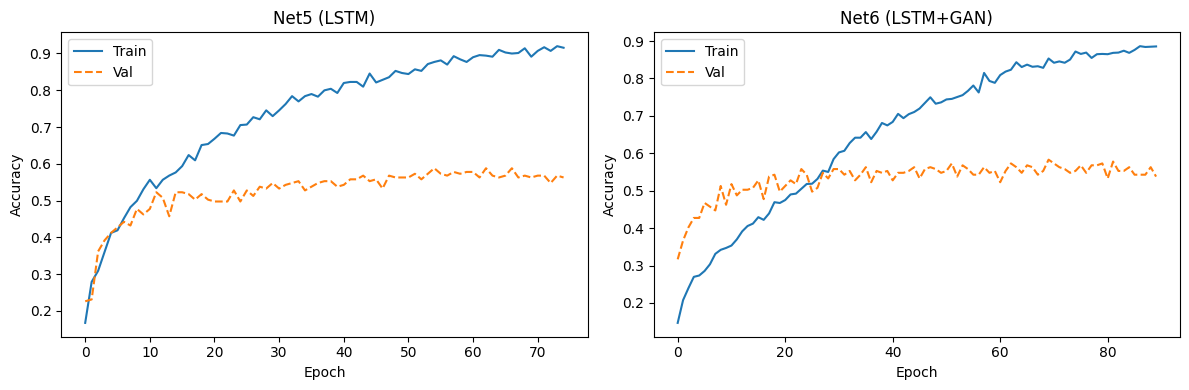


Net5 Test Accuracy : 0.6436
Net6 Test Accuracy : 0.6139
GAN delta          : -0.0297


In [19]:
# Net5 vs Net6 plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, lbl in zip(axes, [hist5, hist6], ['Net5 (LSTM)', 'Net6 (LSTM+GAN)']):
    ax.plot(hist['train_acc'], label='Train')
    ax.plot(hist['val_acc'],   label='Val', linestyle='--')
    ax.set_title(lbl); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend()
plt.tight_layout()
plt.savefig('net56_acc.png', dpi=150)
plt.show()

print(f'\nNet5 Test Accuracy : {acc5:.4f}')
print(f'Net6 Test Accuracy : {acc6:.4f}')
print(f'GAN delta          : {acc6 - acc5:+.4f}')

### Final Results Summary — All Networks

In [20]:
# ── Final Results Summary ─────────────────────────────────────────────────────
all_results = {
    'Net1 — Fully Connected'          : (acc1_50,  acc1_100, '-'),
    'Net2 — CNN'                      : (acc2_50,  acc2_100, '-'),
    'Net3 — CNN + BatchNorm'          : (acc3_50,  acc3_100, '-'),
    'Net4 — CNN + BatchNorm + RMSprop': (acc4_50,  acc4_100, '-'),
    'Net5 — LSTM (audio)'             : ('-',       '-',    acc5),
    'Net6 — LSTM + GAN (audio)'       : ('-',       '-',    acc6),
}

print(f"\n{'Model':<35} {'50ep':>8} {'100ep':>8} {'Converge':>10}")
print('-' * 65)
for name, (a50, a100, ac) in all_results.items():
    def fmt(v): return f'{v:.4f}' if isinstance(v, float) else str(v)
    print(f'{name:<35} {fmt(a50):>8} {fmt(a100):>8} {fmt(ac):>10}')


Model                                   50ep    100ep   Converge
-----------------------------------------------------------------
Net1 — Fully Connected                0.4752   0.3663          -
Net2 — CNN                            0.4257   0.5050          -
Net3 — CNN + BatchNorm                0.6634   0.6436          -
Net4 — CNN + BatchNorm + RMSprop      0.5842   0.6436          -
Net5 — LSTM (audio)                        -        -     0.6436
Net6 — LSTM + GAN (audio)                  -        -     0.6139
